In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import ticker as mticker        # <<– fixed import
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.float_format', '{:,.2f}'.format)
pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 120)

#Chart style
plt.rcParams['figure.dpi'] = 130
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print("Ready!")
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.float_format', '{:,.2f}'.format)
pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 120)

#Chart style
plt.rcParams['figure.dpi'] = 130
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print("Ready!")

Ready!
Ready!


In [2]:
df = pd.read_csv('data/cleaned/master_annual.csv')

print(f"Shape: {df.shape}")
print(f"Years: {df['year'].tolist()}")
print()
print(df.describe().round(1))

Shape: (7, 45)
Years: [2018, 2019, 2020, 2021, 2022, 2023, 2024]

          year  inflation_pct  gdp_per_capita_usd  gdp_per_capita_kes  gdp_growth_pct  cumulative_price_index  \
count     7.00           7.00                7.00                7.00            7.00                    7.00   
mean  2,021.00           5.90            1,995.80          232,142.00            4.80                  119.90   
std       2.20           1.30              108.00           38,351.10            2.40                   16.00   
min   2,018.00           4.50            1,836.50          186,035.60           -0.30                  100.00   
25%   2,019.50           5.00            1,935.10          202,573.00            4.80                  108.10   
50%   2,021.00           5.40            1,960.40          226,002.50            5.10                  117.70   
75%   2,022.50           6.90            2,085.50          260,154.80            5.70                  131.60   
max   2,024.00           7.70 

**What Story am I telling?** 
Our 6 charts — in story order:
- Chart 1 — The Illusion of Growth
Dual line chart: nominal vs real GDP per capita growth % vs 2018. The gap between the two lines IS the story.
- Chart 2 — The Shrinking Shilling
Single line: purchasing power of KES 1,000 over time. Simple, visceral, anyone understands it.
- Chart 3 — What Rose Fastest
Horizontal bar chart: % price change by CPI category 2019→2023, sorted, colour-coded by budget weight. Shows food and transport dominating.
- Chart 4 — Real Wages Falling
Grouped bar or line chart: nominal vs real monthly wage 2019–2023. The divergence tells the wage erosion story.
- Chart 5 — The Poor Pay More
Line chart: inflation by income group 2019–2023. Lower income always above upper income after 2019.
- Chart 6 — The Fuel Shock
Multi-line: petrol, diesel, kerosene prices 2019–2023. Sets context for transport and food inflation.

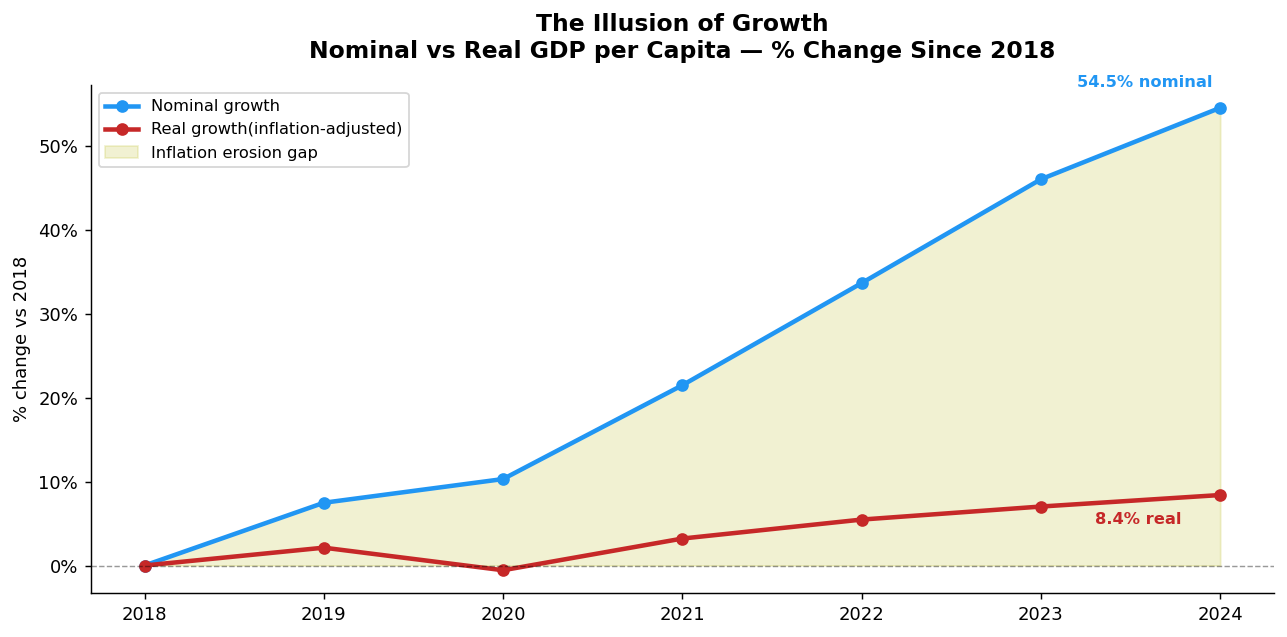

Chart 1 saved!


In [5]:
# Chart 1 : The Illusion of Growth  
fig, ax = plt.subplots(figsize=(10,5))

years = df['year']

ax.plot(years,df['nominal_growth_vs_2018_pct'],
        color='#2196F3', linewidth=2.5, marker='o', markersize=6, label='Nominal growth')

ax.plot(years, df['real_growth_vs_2018_pct'],
        color='#C62828', linewidth=2.5, marker='o', markersize=6, label='Real growth(inflation-adjusted)')

# Shade the gap between the two lines
ax.fill_between(years,
                df['nominal_growth_vs_2018_pct'],
                alpha=0.2, color='C62828', label='Inflation erosion gap')

# Annotate the 2024 endpoints
ax.annotate('54.5% nominal', 
            xy=(2024, 54.5), xytext=(2023.2, 57),
            fontsize=9, color='#2196F3', fontweight='bold')

ax.annotate('8.4% real', 
            xy=(2024, 8.4), xytext=(2023.3, 5),
            fontsize=9, color='#C62828', fontweight='bold')

# Reference line at 0
ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.4)

ax.set_title('The Illusion of Growth\nNominal vs Real GDP per Capita — % Change Since 2018', 
             fontsize=13, fontweight='bold', pad=15)
ax.set_ylabel('% change vs 2018', fontsize=10)
ax.set_xlabel('')
ax.set_xticks(years)
ax.legend(fontsize=9)
ax.yaxis.set_major_formatter(mticker.PercentFormatter())

plt.tight_layout()
plt.savefig('visuals/chart1_nominal_vs_real_growth.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 1 saved!")

## Chart 1 — The Illusion of Growth

Between 2018 and 2024, Kenya's GDP per capita in Shillings grew **54.5% in nominal terms** — 
a figure that appears in headlines and government reports as evidence of economic progress.

But when adjusted for cumulative inflation — which reached **42.6% over the same period** — 
real GDP per capita grew only **8.4%**. That is less than 1.4% per year in actual purchasing 
power improvement.

The shaded area between the two lines represents **inflation erosion**: income growth that 
existed statistically but disappeared at the supermarket, the fuel pump, and the rent payment.

Notable points:
- **2020**: Real GDP per capita briefly turned **negative (-0.6%)** — the average Kenyan was 
  poorer in real terms than in 2018, driven by COVID-19 disruptions
- **2022–2023**: Inflation peaked at 7.7%, widening the gap to its largest point
- **2024**: Some recovery as inflation eased to 4.5%, but the gap never closed

> The core finding: for every KES 100 of income growth reported between 2018 and 2024, 
> only KES 15 represented a real improvement in living standards. The other KES 85 was 
> consumed by rising prices.

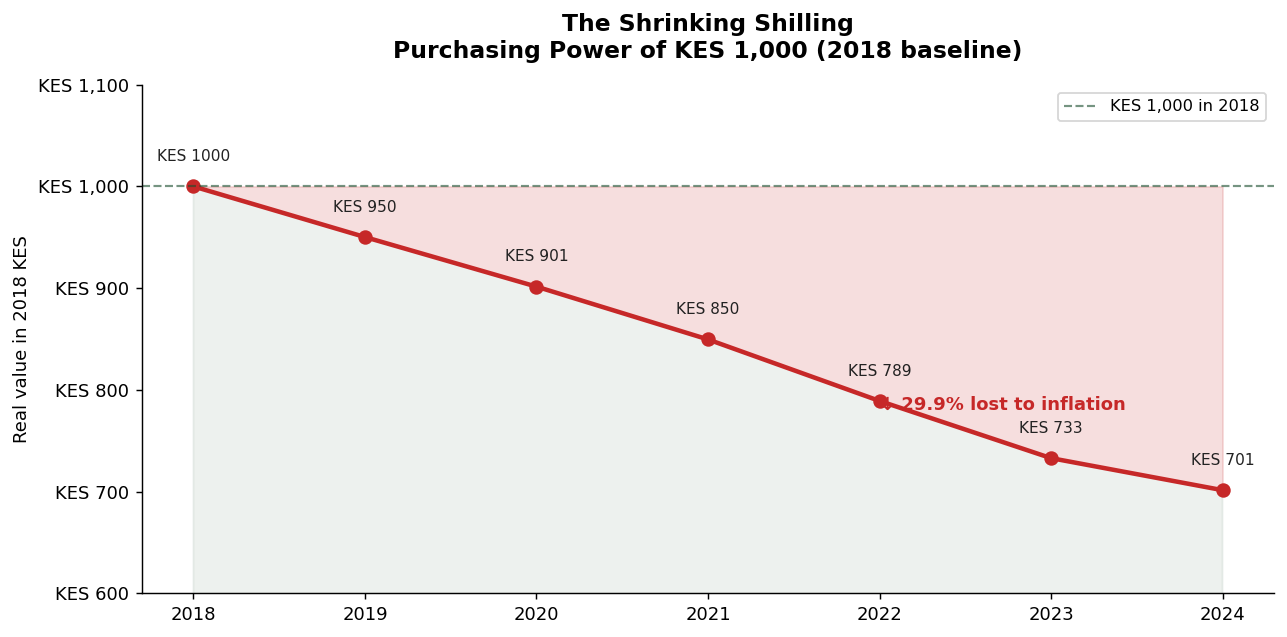

Chart 2 saved ✓


In [10]:
# Chart 2 — The Shrinking Shilling  
fig, ax = plt.subplots(figsize=(10, 5))

years = df['year']
power = df['purchasing_power_of_1000kes']

# Fill area under the line to make the decline feel heavy
ax.fill_between(years, power, 1000, alpha=0.15, color='#C62828')
ax.fill_between(years, power, 0,   alpha=0.08, color='#1A4D2E')

ax.plot(years, power,
        color='#C62828', linewidth=2.5, marker='o', markersize=7)

# Annotate each year with its value
for year, val in zip(years, power):
    ax.annotate(f'KES {val:.0f}',
                xy=(year, val),
                xytext=(0, 14),
                textcoords='offset points',
                ha='center', fontsize=8.5, color='#222222')

# Reference line at 1000 — where we started
ax.axhline(1000, color='#1A4D2E', linewidth=1.2, 
           linestyle='--', alpha=0.6, label='KES 1,000 in 2018')

# Annotate the total loss
ax.annotate('↓ 29.9% lost to inflation',
            xy=(2022, 780), fontsize=10,
            color='#C62828', fontweight='bold')

ax.set_title('The Shrinking Shilling\nPurchasing Power of KES 1,000 (2018 baseline)',
             fontsize=13, fontweight='bold', pad=15)
ax.set_ylabel('Real value in 2018 KES', fontsize=10)
ax.set_ylim(600, 1100)
ax.set_xticks(years)
ax.legend(fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'KES {x:,.0f}'))

plt.tight_layout()
plt.savefig('visuals/chart2_purchasing_power.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 2 saved ✓")

## Chart 2 — The Shrinking Shilling

### What this chart shows
Every Kenyan who held cash, earned a fixed salary, or saved money in a bank account 
between 2018 and 2024 experienced what this chart makes visible: their money bought 
less every single year, without exception.

KES 1,000 in 2018 had the purchasing power of only **KES 701 by 2024** — a loss of 
**KES 299, or 29.9%, in six years**. This is not a market crash or a one-off shock. 
It is the quiet, compounding effect of persistent inflation eroding value year after year.

### The numbers year by year
| Year | Purchasing Power of KES 1,000 | Annual Loss |
|------|-------------------------------|-------------|
| 2018 | KES 1,000 (baseline)          | —           |
| 2019 | KES 950                       | -KES 50     |
| 2020 | KES 901                       | -KES 49     |
| 2021 | KES 850                       | -KES 51     |
| 2022 | KES 789                       | -KES 61     |
| 2023 | KES 733                       | -KES 56     |
| 2024 | KES 701                       | -KES 32     |

The steepest single-year drop was **2022: -KES 61**, when inflation hit its peak of 
7.7% — driven by the global commodity shock following Russia's invasion of Ukraine, 
which pushed fuel and food prices to multi-year highs in Kenya.

### Why this matters more than the inflation rate alone
Most people encounter inflation as a percentage — "inflation is 7.7%" — which feels 
abstract. This chart translates that percentage into something concrete: if you earned 
KES 50,000 a month in 2018 and your salary never changed, by 2024 you would need 
**KES 71,300** just to maintain the same standard of living. That KES 21,300 gap is 
what inflation silently took from you.

For workers on fixed government salaries, pension recipients, and the majority of 
informal sector workers whose incomes do not automatically adjust to inflation, this 
chart is not an abstraction. It is their lived financial reality.

### The compounding effect
Inflation compounds like interest in reverse. A 5% inflation rate does not just 
reduce your purchasing power by 5% and stop — it reduces it by 5%, then applies 
the next year's inflation to an already-reduced base. By 2024, the cumulative price 
level was **42.6% higher** than 2018. That is why the line falls faster in later 
years than the annual inflation rate alone would suggest.

### Connection to the broader analysis
This chart sets the foundation for everything that follows:
- **Chart 3** will show *which* specific goods and services drove this decline
- **Chart 4** will show whether wages kept pace — or fell behind
- **Chart 5** will show that this burden was not shared equally across income groups

> A 29.9% loss in purchasing power over 6 years means that economic growth, 
> wage increases, and savings all had to clear a very high bar just to break even. 
> Most Kenyans did not clear that bar.

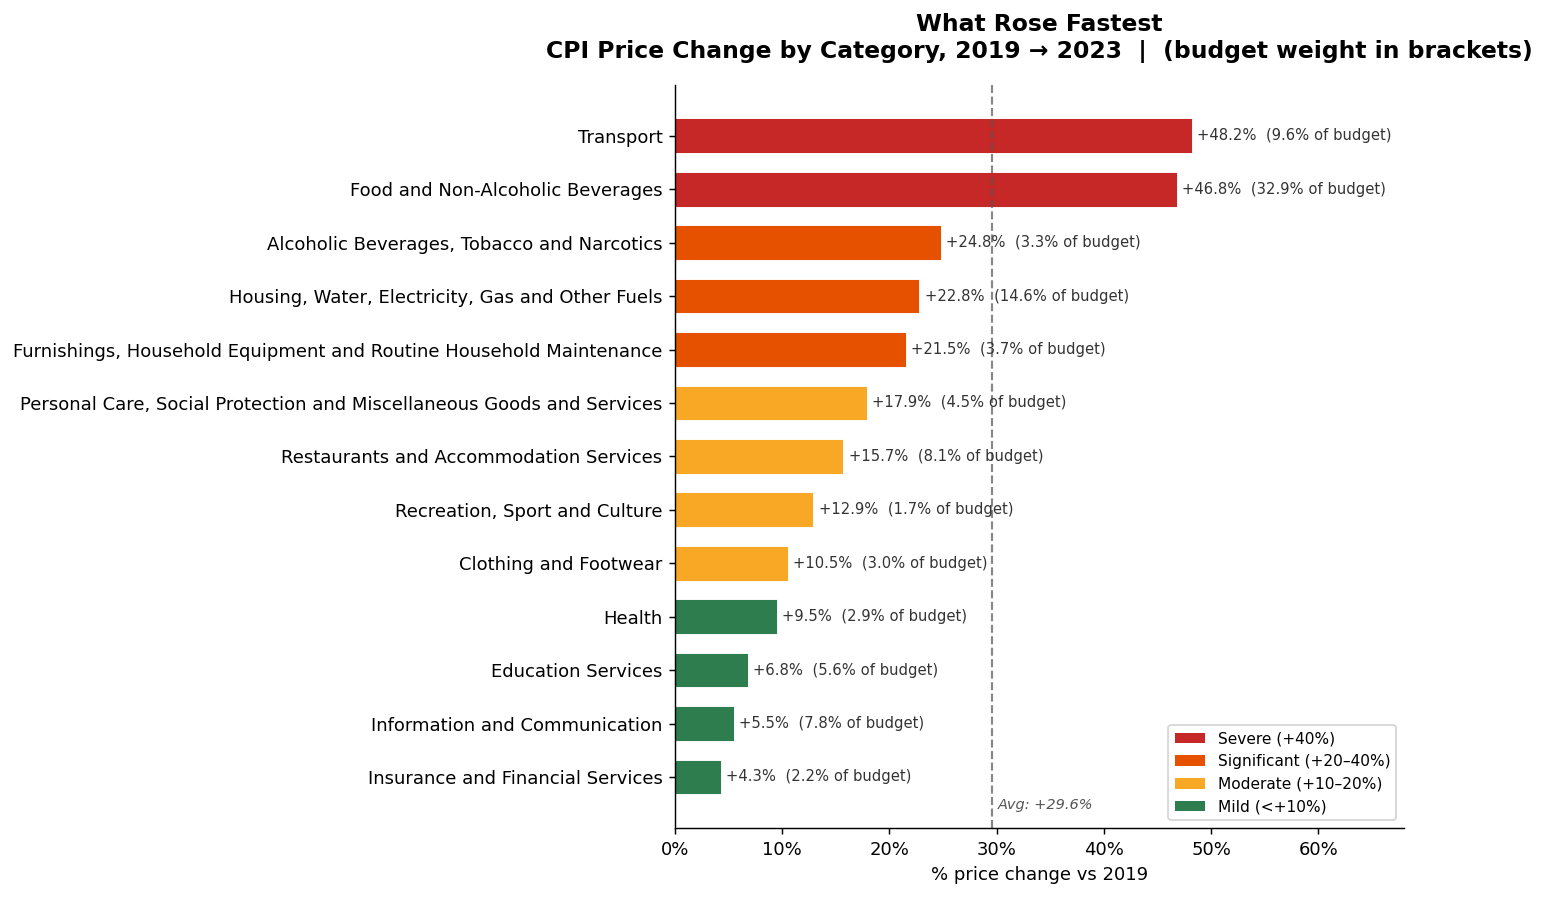

Chart 3 saved ✓


In [11]:
#Chart 3 — What Rose Fastest
# CPI data — % change 2019 to 2023 by category
cpi_cats = pd.read_csv('data/cleaned/knbs_cpi_categories.csv')

# Get 2023 price change vs 2019 for each category, excluding the overall average
changes = cpi_cats[
    (cpi_cats['year'] == 2023) &
    (cpi_cats['category'] != 'Weighted Average of All Items')
][['category', 'weight_pct', 'price_change_vs_2019_pct']].sort_values(
    'price_change_vs_2019_pct', ascending=True  # ascending=True so highest is at top of horizontal bar
)

# Colour logic:
# Red   — high weight AND high price change (the dangerous categories)
# Orange — high price change but lower weight
# Green  — low price change (relatively safe)
def bar_color(row):
    if row['price_change_vs_2019_pct'] >= 40:
        return '#C62828'   # red — severe
    elif row['price_change_vs_2019_pct'] >= 20:
        return '#E65100'   # orange — significant
    elif row['price_change_vs_2019_pct'] >= 10:
        return '#F9A825'   # amber — moderate
    else:
        return '#2E7D4F'   # green — mild

colors = changes.apply(bar_color, axis=1).tolist()

fig, ax = plt.subplots(figsize=(11, 7))

bars = ax.barh(changes['category'], changes['price_change_vs_2019_pct'],
               color=colors, edgecolor='white', linewidth=0.5, height=0.65)

# Add value labels at end of each bar
for bar, (_, row) in zip(bars, changes.iterrows()):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
            f"+{row['price_change_vs_2019_pct']:.1f}%  ({row['weight_pct']:.1f}% of budget)",
            va='center', fontsize=8.2, color='#333333')

# Reference line at overall average
overall_change = cpi_cats[
    (cpi_cats['year'] == 2023) &
    (cpi_cats['category'] == 'Weighted Average of All Items')
]['price_change_vs_2019_pct'].values[0]

ax.axvline(overall_change, color='#555555', linewidth=1.2,
           linestyle='--', alpha=0.7)
ax.text(overall_change + 0.5, -0.6, f'Avg: +{overall_change:.1f}%',
        fontsize=8, color='#555555', style='italic')

ax.set_title('What Rose Fastest\nCPI Price Change by Category, 2019 → 2023  |  (budget weight in brackets)',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('% price change vs 2019', fontsize=10)
ax.set_xlim(0, 68)
ax.xaxis.set_major_formatter(mticker.PercentFormatter())

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#C62828', label='Severe (+40%)'),
    Patch(facecolor='#E65100', label='Significant (+20–40%)'),
    Patch(facecolor='#F9A825', label='Moderate (+10–20%)'),
    Patch(facecolor='#2E7D4F', label='Mild (<+10%)'),
]
ax.legend(handles=legend_elements, fontsize=8.5, loc='lower right')

plt.tight_layout()
plt.savefig('visuals/chart3_cpi_by_category.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 3 saved ✓")

## Chart 3 — What Rose Fastest

### What this chart shows
Not all inflation is equal. This chart breaks down the 29.6% average price increase 
between 2019 and 2023 into its 13 component categories — ranked from highest to lowest 
— with each category's share of the average household budget shown in brackets.

The colour coding reflects severity:
- 🔴 **Red — Severe**: rose more than 40% 
- 🟠 **Orange — Significant**: rose 20–40%
- 🟡 **Amber — Moderate**: rose 10–20%
- 🟢 **Green — Mild**: rose less than 10%

### The two categories that matter most
**Transport (+48.2%, 9.6% of budget)** and **Food (+46.8%, 32.9% of budget)** are the 
two worst performers — and together they account for **42.5% of the average Kenyan 
household's spending**.

This is the structural inequality of inflation in Kenya: the categories that dominate 
poor and middle-income budgets rose the fastest, while categories that wealthier 
households spend more on proportionally — ICT (+5.5%), Insurance (+4.3%), Education 
(+6.8%) — rose the least.

### Category-by-category breakdown

| Category | Price Change | Budget Weight | Severity |
|----------|-------------|---------------|----------|
| Transport | +48.2% | 9.6% | 🔴 Severe |
| Food & Non-Alcoholic Beverages | +46.8% | 32.9% | 🔴 Severe |
| Alcoholic Beverages & Tobacco | +24.8% | 3.3% | 🟠 Significant |
| Housing, Water, Electricity & Gas | +22.8% | 14.6% | 🟠 Significant |
| Furnishings & Household Equipment | +21.5% | 3.7% | 🟠 Significant |
| Personal Care & Miscellaneous | +17.9% | 4.5% | 🟡 Moderate |
| Restaurants & Accommodation | +15.7% | 8.1% | 🟡 Moderate |
| Recreation, Sport & Culture | +12.9% | 1.7% | 🟡 Moderate |
| Clothing & Footwear | +10.5% | 3.0% | 🟡 Moderate |
| Health | +9.5% | 2.9% | 🟢 Mild |
| Education Services | +6.8% | 5.6% | 🟢 Mild |
| Information & Communication | +5.5% | 7.8% | 🟢 Mild |
| Insurance & Financial Services | +4.3% | 2.2% | 🟢 Mild |

### Why transport and food rose so sharply
These two categories are directly linked to fuel prices. Between 2019 and 2023:
- Petrol rose **+77.4%** (KES 109 → KES 194 per litre)
- Diesel rose **+75.2%** (KES 103 → KES 180 per litre)

In Kenya, where **over 80% of freight moves by road**, fuel costs flow directly into 
the price of every product on every shelf in every shop across the country. The fuel 
shock did not stay at the pump — it travelled through the entire supply chain and 
landed on the dinner table.

### The ICT exception
Information and Communication rising only +5.5% is notable. Mobile data and airtime 
costs have remained relatively stable due to competition among telecoms providers and 
infrastructure investment. This is one area where Kenyan consumers genuinely benefited 
from market dynamics holding prices down — even as everything around it rose.

### What this means for low-income households
A household spending KES 30,000 per month allocates roughly:
- **KES 9,870 on food** (32.9%) → now costs KES 14,490 (+KES 4,620)
- **KES 2,880 on transport** (9.6%) → now costs KES 4,270 (+KES 1,390)
- **KES 4,380 on housing** (14.6%) → now costs KES 5,380 (+KES 1,000)

Those three categories alone add **KES 7,010 per month** to a household's costs — 
a 23% increase in total monthly spending just to maintain the same standard of living, 
with no income change assumed.

> The average masks the structure. A single inflation number tells you how much 
> prices rose. This chart tells you *who paid for it*.

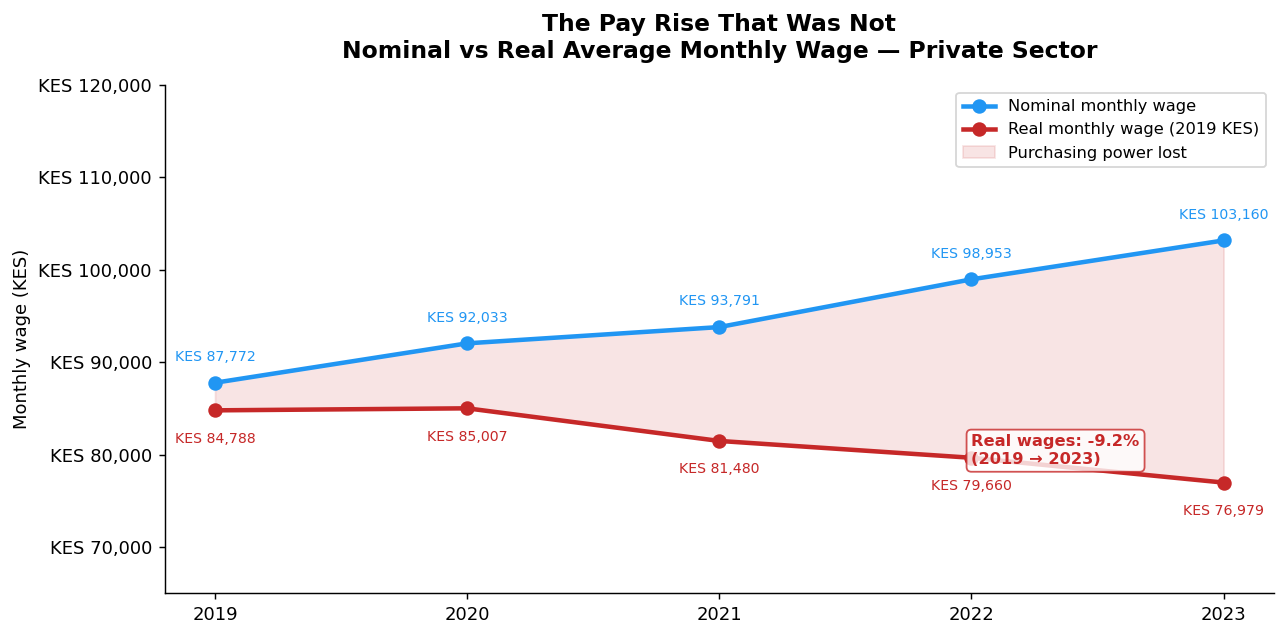

Chart 4 saved ✓


In [12]:
# Filter to years where wage data exists (2019-2023)
wages_df = df[df['avg_nominal_monthly_wage'].notna()].copy()

years_w = wages_df['year']
nominal = wages_df['avg_nominal_monthly_wage']
real    = wages_df['avg_real_monthly_wage']

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(years_w, nominal,
        color='#2196F3', linewidth=2.5, marker='o', markersize=7,
        label='Nominal monthly wage')

ax.plot(years_w, real,
        color='#C62828', linewidth=2.5, marker='o', markersize=7,
        label='Real monthly wage (2019 KES)')

# Shade the gap
ax.fill_between(years_w, nominal, real,
                alpha=0.12, color='#C62828', label='Purchasing power lost')

# Annotate start and end values for both lines
for year, nom, rl in zip(years_w, nominal, real):
    ax.annotate(f'KES {nom:,.0f}',
                xy=(year, nom), xytext=(0, 12),
                textcoords='offset points',
                ha='center', fontsize=7.8, color='#2196F3')
    ax.annotate(f'KES {rl:,.0f}',
                xy=(year, rl), xytext=(0, -18),
                textcoords='offset points',
                ha='center', fontsize=7.8, color='#C62828')

# Annotate the real wage change
ax.annotate('Real wages: -9.2%\n(2019 → 2023)',
            xy=(2022, 79000), fontsize=9,
            color='#C62828', fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', 
                      edgecolor='#C62828', alpha=0.8))

ax.set_title('The Pay Rise That Was Not\nNominal vs Real Average Monthly Wage — Private Sector',
             fontsize=13, fontweight='bold', pad=15)
ax.set_ylabel('Monthly wage (KES)', fontsize=10)
ax.set_xticks(years_w)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'KES {x:,.0f}'))
ax.legend(fontsize=9)
ax.set_ylim(65000, 120000)

plt.tight_layout()
plt.savefig('visuals/chart4_nominal_vs_real_wages.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 4 saved ✓")

## Chart 4 — The Pay Rise That Was Not

### What this chart shows
Every year from 2019 to 2023, the average private sector Kenyan worker received 
a nominal pay increase. Their payslip showed a higher number. Their bank account 
received more Shillings. And yet, in terms of what that money could actually buy, 
they were getting **poorer every single year**.

This chart makes that contradiction visible. The blue line (nominal wage) rises 
steadily. The red line (real wage, adjusted to 2019 Shillings) falls steadily. 
The shaded area between them is purchasing power that existed on paper but 
evaporated at the checkout counter.

### The numbers
| Year | Nominal Monthly Wage | Real Monthly Wage | Real Change vs 2019 |
|------|---------------------|-------------------|---------------------|
| 2019 | KES 87,772 | KES 84,788 | 0.0% (baseline) |
| 2020 | KES 92,033 | KES 85,007 | +0.3% |
| 2021 | KES 93,791 | KES 81,480 | -3.9% |
| 2022 | KES 98,953 | KES 79,660 | -6.0% |
| 2023 | KES 103,160 | KES 76,979 | -9.2% |

Nominal wages rose **17.5%** between 2019 and 2023.
Real wages fell **9.2%** over the same period.

That is a **26.7 percentage point gap** — all of it explained by inflation 
running faster than pay increases.

### What 2020 reveals
The one moment the lines nearly converge is 2020 — the COVID year. Real wages 
barely moved (+0.3%) because inflation was also suppressed that year as economic 
activity collapsed and demand fell. It is a reminder that low inflation is not 
always a sign of a healthy economy — sometimes it just means people have stopped 
spending because they cannot afford to.

From 2021 onwards, as the economy reopened and supply chain disruptions drove 
global commodity prices up, inflation accelerated and the real wage line broke 
downward sharply. The worker who earned KES 93,791 in 2021 was effectively 
earning the equivalent of KES 81,480 in 2019 money — a KES 7,308 monthly loss 
in purchasing power, even with a nominal raise.

### The formal sector caveat
This data covers **formal sector private employees only** — the workers with 
payslips, contracts, and recorded wages. Kenya's informal sector employs an 
estimated **83% of the workforce**. Informal workers typically have no 
automatic wage adjustment mechanism, no union negotiations, and no guaranteed 
minimum review cycle.

If formal sector real wages fell 9.2%, the situation for informal sector workers 
— market traders, boda boda operators, casual labourers, domestic workers — 
was almost certainly worse. The formal sector data is the floor, not the ceiling, 
of wage erosion in Kenya.

### The agriculture finding
When broken down by industry, the sharpest real wage decline belongs to 
**Agriculture, forestry and fishing** — Kenya's largest employer by headcount:

- 2019 real wage: KES 356,886 annually (KES 29,741/month)
- 2023 real wage: KES 302,573 annually (KES 25,214/month)
- Decline: **-15.3% in real terms**

The people growing Kenya's food got poorer the fastest — in the same years 
that food prices rose 46.8%.

> Nominal wages are a story you tell yourself. 
> Real wages are what you can actually eat, ride, and live on. 
> For the average Kenyan private sector worker, that number fell every year 
> from 2021 to 2023 without interruption.

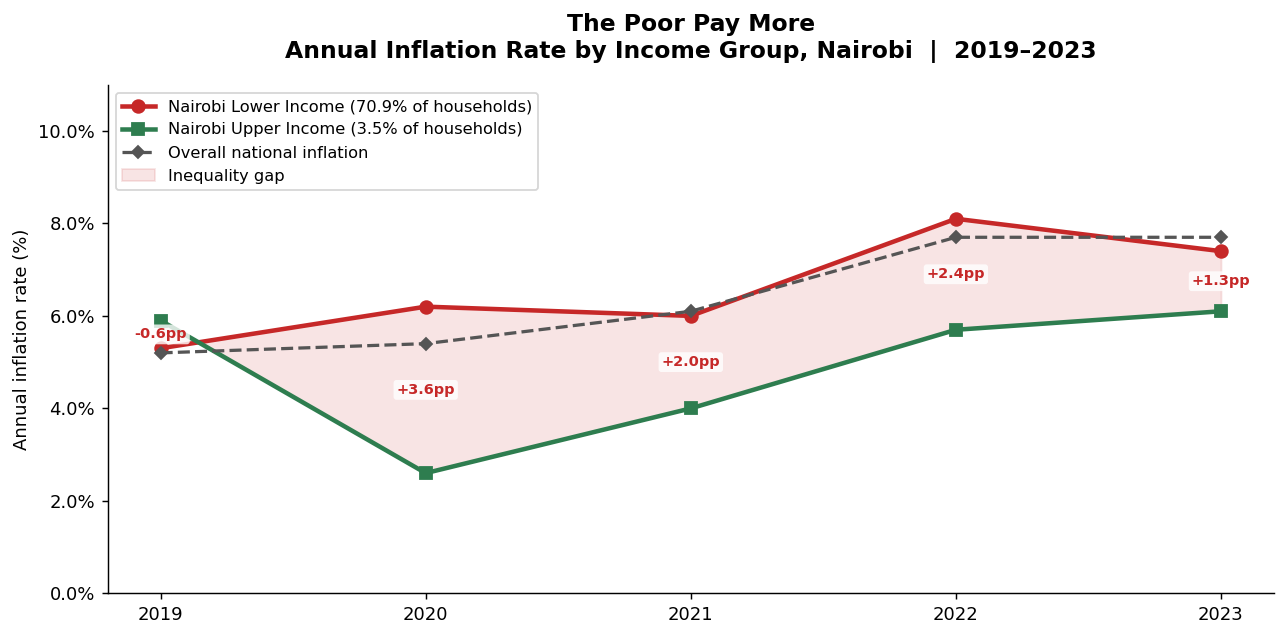

Chart 5 saved ✓


In [13]:
# Chart 5 — The Poor Pay More. 
# Filter income inflation data
inc_df = df[df['inflation_lower_income'].notna()].copy()

years_i = inc_df['year']
lower   = inc_df['inflation_lower_income']
upper   = inc_df['inflation_upper_income']
overall = inc_df['inflation_overall_knbs']

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(years_i, lower,
        color='#C62828', linewidth=2.5, marker='o', markersize=7,
        label='Nairobi Lower Income (70.9% of households)')

ax.plot(years_i, upper,
        color='#2E7D4F', linewidth=2.5, marker='s', markersize=7,
        label='Nairobi Upper Income (3.5% of households)')

ax.plot(years_i, overall,
        color='#555555', linewidth=1.8, marker='D', markersize=5,
        linestyle='--', label='Overall national inflation')

# Shade gap between lower and upper
ax.fill_between(years_i, lower, upper,
                alpha=0.12, color='#C62828', label='Inequality gap')

# Annotate the gap at each year
for year, lo, up in zip(years_i, lower, upper):
    gap = lo - up
    mid = (lo + up) / 2
    if abs(gap) > 0.3:  # only annotate meaningful gaps
        sign = '+' if gap > 0 else ''
        ax.annotate(f'{sign}{gap:.1f}pp',
                    xy=(year, mid),
                    ha='center', va='center',
                    fontsize=8, color='#C62828', fontweight='bold',
                    bbox=dict(boxstyle='round,pad=0.2', 
                              facecolor='white', edgecolor='none', alpha=0.8))

ax.set_title('The Poor Pay More\nAnnual Inflation Rate by Income Group, Nairobi  |  2019–2023',
             fontsize=13, fontweight='bold', pad=15)
ax.set_ylabel('Annual inflation rate (%)', fontsize=10)
ax.set_xticks(years_i)
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.legend(fontsize=9, loc='upper left')
ax.set_ylim(0, 11)

plt.tight_layout()
plt.savefig('visuals/chart5_inflation_by_income.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 5 saved ✓")

## Chart 5 — The Poor Pay More

### What this chart shows
Inflation is reported as a single national number. But that number is an average — 
and averages hide who actually bears the cost. This chart splits the official 
inflation figure into three groups: Nairobi lower income households, Nairobi upper 
income households, and the overall national rate.

The finding is consistent and unambiguous: **from 2020 onwards, lower income 
households experienced higher inflation every single year than upper income 
households.** The gap ranged from 1.3 to 3.6 percentage points — not a rounding 
error, but a structural difference in how inflation lands depending on where you 
sit in the income distribution.

### Who these groups are
These are KNBS-defined income categories based on February 2016 spending levels:

| Group | Monthly Spending Threshold | Share of Nairobi Households |
|-------|---------------------------|----------------------------|
| Lower Income | ≤ KES 46,355/month | **70.9%** |
| Middle Income | KES 46,356 – KES 184,394/month | 25.6% |
| Upper Income | ≥ KES 184,395/month | **3.5%** |

When this chart says lower income households paid more — it is talking about 
**nearly 71% of all Nairobi households.** This is not a fringe group. 
This is most of the city.

### The gap year by year
| Year | Lower Income | Upper Income | Gap |
|------|-------------|-------------|-----|
| 2019 | 5.3% | 5.9% | -0.6pp (upper paid more) |
| 2020 | 6.2% | 2.6% | **+3.6pp** |
| 2021 | 6.0% | 4.0% | +2.0pp |
| 2022 | 8.1% | 5.7% | +2.4pp |
| 2023 | 7.4% | 6.1% | +1.3pp |

2019 is the only year upper income households experienced higher inflation — 
driven by elevated spending in discretionary categories that year. Every year 
after that, the pattern reverses and holds.

### Why 2020 is the most revealing year
In 2020, upper income inflation collapsed to **2.6%** while lower income 
inflation remained at **6.2%** — a gap of 3.6 percentage points, the widest 
in the dataset.

The reason is structural. When COVID-19 hit and economic activity contracted, 
discretionary spending fell sharply. Restaurants closed. Travel stopped. 
Entertainment spending dropped to zero. These categories — which upper income 
households spend more on — deflated or stagnated, pulling their effective 
inflation rate down.

Lower income households, however, cannot reduce spending on food, rent, 
transport, and cooking fuel. Those categories kept rising regardless of 
lockdowns. You cannot stop eating to wait out a pandemic.

### Why this happens — the budget weight explanation
The gap is not because shops charge lower income people higher prices. 
It is because lower income households spend a larger share of their budget 
on the categories that rose fastest:

- **Food**: 32.9% of the average budget, rose +46.8%
- **Transport**: 9.6% of the average budget, rose +48.2%  
- **Housing & utilities**: 14.6% of the average budget, rose +22.8%

A wealthy household that spends 10% of income on food absorbs food inflation 
very differently from a poor household spending 50% of income on food. 
Same price increase. Completely different impact.

### The compounding inequality
This chart shows annual rates — but the damage compounds. A lower income 
household that experienced 3.6pp more inflation in 2020, then 2.0pp more 
in 2021, then 2.4pp more in 2022, has accumulated a meaningful real income 
disadvantage relative to an upper income household over the same period — 
even if both received identical nominal wage increases.

Inflation is a regressive tax. It takes a larger share from those who can 
least afford to give it.

> The national inflation number is 7.7%. 
> For 70.9% of Nairobi, the real number was higher. 
> For the 3.5% at the top, it was lower. 
> One statistic. Two completely different lived realities.

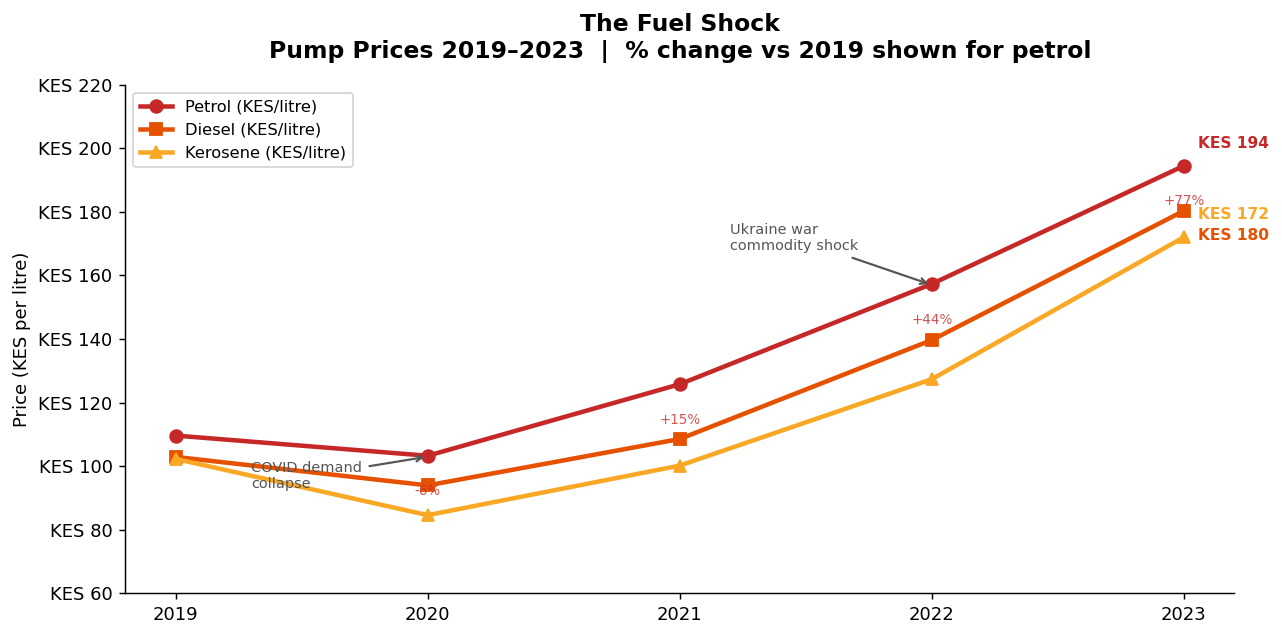

Chart 6 saved ✓


In [14]:
# Chart 6, The Fuel Shock.
# Filter to years where fuel data exists (2019-2023)
fuel_df = df[df['petrol_kes_litre'].notna()].copy()

years_f = fuel_df['year']

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(years_f, fuel_df['petrol_kes_litre'],
        color='#C62828', linewidth=2.5, marker='o', markersize=7,
        label='Petrol (KES/litre)')

ax.plot(years_f, fuel_df['diesel_kes_litre'],
        color='#E65100', linewidth=2.5, marker='s', markersize=7,
        label='Diesel (KES/litre)')

ax.plot(years_f, fuel_df['kerosene_kes_litre'],
        color='#F9A825', linewidth=2.5, marker='^', markersize=7,
        label='Kerosene (KES/litre)')

# Annotate end values only — 2023
for col, color, offset in [
    ('petrol_kes_litre',   '#C62828', 10),
    ('diesel_kes_litre',   '#E65100', -16),
    ('kerosene_kes_litre', '#F9A825', 10),
]:
    val = fuel_df[fuel_df['year'] == 2023][col].values[0]
    ax.annotate(f'KES {val:.0f}',
                xy=(2023, val), xytext=(8, offset),
                textcoords='offset points',
                fontsize=8.5, color=color, fontweight='bold')

# Annotate the 2022 spike explanation
ax.annotate('Ukraine war\ncommodity shock',
            xy=(2022, 157), xytext=(2021.2, 168),
            fontsize=8, color='#555555',
            arrowprops=dict(arrowstyle='->', color='#555555', lw=1.2))

# Annotate 2020 dip
ax.annotate('COVID demand\ncollapse',
            xy=(2020, 103), xytext=(2019.3, 93),
            fontsize=8, color='#555555',
            arrowprops=dict(arrowstyle='->', color='#555555', lw=1.2))

# % change labels on petrol line only
for year, val, chg in zip(years_f, 
                           fuel_df['petrol_kes_litre'],
                           fuel_df['petrol_kes_litre_change_vs_2019_pct']):
    if year != 2019:
        ax.annotate(f'{chg:+.0f}%',
                    xy=(year, val), xytext=(0, -22),
                    textcoords='offset points',
                    ha='center', fontsize=7.5, color='#C62828', alpha=0.8)

ax.set_title('The Fuel Shock\nPump Prices 2019–2023  |  % change vs 2019 shown for petrol',
             fontsize=13, fontweight='bold', pad=15)
ax.set_ylabel('Price (KES per litre)', fontsize=10)
ax.set_xticks(years_f)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'KES {x:,.0f}'))
ax.legend(fontsize=9, loc='upper left')
ax.set_ylim(60, 220)

plt.tight_layout()
plt.savefig('visuals/chart6_fuel_prices.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 6 saved ✓")

## Chart 6 — The Fuel Shock

### What this chart shows
Fuel is the circulatory system of the Kenyan economy. Every matatu fare, every 
trucked delivery of maize, every generator running a small business, every 
kerosene stove in a low-income household — all of it runs on petrol, diesel, 
or kerosene. When fuel prices rise, everything rises with them.

This chart tracks the annual average pump price of all three fuels from 2019 
to 2023. The shape is unmistakable: a brief dip in 2020, then an unrelenting 
climb that did not stop until the end of the dataset.

### The numbers
| Year | Petrol (KES/L) | Diesel (KES/L) | Kerosene (KES/L) | Petrol vs 2019 |
|------|---------------|----------------|------------------|----------------|
| 2019 | KES 110 | KES 103 | KES 102 | baseline |
| 2020 | KES 103 | KES 94 | KES 85 | -6% |
| 2021 | KES 126 | KES 109 | KES 100 | +15% |
| 2022 | KES 157 | KES 140 | KES 127 | +44% |
| 2023 | KES 194 | KES 180 | KES 172 | +77% |

By 2023, petrol had risen **77%**, diesel **75%**, and kerosene **68%** 
compared to 2019. These are not marginal adjustments — they are transformative 
price shocks that rippled through every sector of the economy.

### The 2020 dip — a false reprieve
When COVID-19 hit in early 2020, global oil demand collapsed as economies 
locked down and air travel ceased. Brent crude briefly turned negative in 
April 2020 — an unprecedented event. Kenyan pump prices fell accordingly, 
with kerosene dropping to KES 85 per litre, its lowest point in the dataset.

For Kenyan households, this was a brief moment of relief — but it masked 
the structural pressures building underneath. Supply chains were contracting, 
global shipping costs were rising, and the conditions for the post-COVID 
inflation surge were already forming.

### The Ukraine shock — the breaking point
The sharpest acceleration begins between 2021 and 2022, when Russia's 
invasion of Ukraine in February 2022 triggered a global commodity crisis. 
Kenya felt this through three simultaneous channels:

**1. Direct fuel price transmission** — Global oil prices surged above 
USD 120 per barrel. Since Kenya imports 100% of its refined petroleum 
products, this translated immediately to pump prices. Petrol jumped from 
KES 126 to KES 157 in a single year — a KES 31 per litre increase.

**2. Food price transmission** — Ukraine and Russia together supply roughly 
30% of global wheat exports. Kenya, a wheat importer, saw flour and bread 
prices spike. This is one of the primary drivers behind food inflation 
reaching +46.8% by 2023.

**3. Fertiliser price transmission** — Russia is a major fertiliser exporter. 
Fertiliser shortages raised input costs for Kenyan farmers, compressing 
margins and pushing up domestic food production costs from the supply side.

### Kerosene — the hidden burden
Kerosene is the fuel of the poorest households. It powers the cooking 
stoves in informal settlements where LPG is unaffordable and electricity 
connections are unreliable. A 68% increase in kerosene prices is not an 
inconvenience for those households — it is a direct hit to the cost of 
cooking a meal.

At the same time, a 13kg LPG cylinder rose from **KES 2,161 in 2019 to 
KES 2,991 in 2023** — a 38.4% increase. Households that tried to switch 
from kerosene to LPG to escape rising kerosene costs found that LPG had 
also become significantly more expensive.

### The transmission mechanism — why fuel explains everything
This chart is the causal engine behind Charts 3, 4, and 5:

- **Chart 3** showed transport (+48%) and food (+47%) as the fastest-rising 
  categories → both driven directly by fuel costs
- **Chart 4** showed real wages falling → partly because transport costs 
  consumed a larger share of take-home pay before workers even reached 
  their jobs
- **Chart 5** showed lower income households bearing higher inflation → 
  because fuel-dependent categories dominate their budgets

The fuel shock was not just an energy story. It was the mechanism through 
which a global geopolitical event — a war in Eastern Europe — arrived in 
a Kenyan kitchen in the form of a more expensive ugali, a higher matatu 
fare, and a cooking stove that cost more to light.

> Petrol at KES 194 in 2023 versus KES 110 in 2019 is a 77% increase. 
> But the true cost was not paid at the pump. 
> It was paid in every shop, every market stall, and every household 
> budget across the country.